In [48]:
import seaborn as sns
import matplotlib.pyplot as plt 

In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv("../data/raw/orders.csv")

In [3]:
df.head(4)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),delivery_time_mins,weather_clean,is_late,distance_km
0,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25/03/22,19:45:00,...,Snack,scooter,1,No,Metropolitian,(min) 33,33,Stormy,1,20.18
1,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19/03/22,8:30:00,...,Drinks,motorcycle,1,No,Urban,(min) 26,26,Sandstorms,0,1.55
2,0x2288,BANGRES09DEL03,32,4.0,12.934179,77.615797,13.024179,77.705797,16/03/22,21:20:00,...,Buffet,motorcycle,1,No,Metropolitian,(min) 47,47,Windy,1,13.97
3,0x9d26,BANGRES17DEL02,26,4.9,12.972532,77.608179,12.992532,77.628179,28/03/22,8:40:00,...,Buffet,scooter,0,No,Metropolitian,(min) 11,11,Stormy,0,3.11


In [4]:
df.shape

(2988, 24)

In [ ]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,delivery_time_mins,is_late,distance_km
count,2988.000000,2988.000000,2988.000000,2988.000000,2988.000000,2988.000000,2988.000000,2988.000000,2988.000000,2988.000000,2988.000000
mean,29.465529,4.633936,12.955616,77.634523,13.017892,77.696798,0.974565,0.739290,26.131861,0.293507,9.668601
std,5.792571,0.323098,0.029753,0.033497,0.046485,0.049589,0.819103,0.562739,9.176141,0.455445,5.585517
min,20.000000,2.500000,12.906229,77.570997,12.916229,77.580997,0.000000,0.000000,10.000000,0.000000,1.550000
25%,24.000000,4.500000,12.934179,77.614293,12.985377,77.660489,0.000000,0.000000,19.000000,0.000000,4.660000
50%,30.000000,4.700000,12.970221,77.640489,13.015662,77.695396,1.000000,1.000000,25.000000,0.000000,9.320000
75%,34.000000,4.900000,12.978453,77.645748,13.049198,77.729386,2.000000,1.000000,32.000000,1.000000,13.970000
max,39.000000,5.000000,13.029198,77.699386,13.159198,77.829386,2.000000,3.000000,54.000000,1.000000,20.180000


In [6]:
df.columns


Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)',
       'delivery_time_mins', 'weather_clean', 'is_late', 'distance_km'],
      dtype='object')

In [9]:
df.select_dtypes(include = 'object').columns

Index(['ID', 'Delivery_person_ID', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Type_of_order', 'Type_of_vehicle', 'Festival', 'City',
       'Time_taken(min)', 'weather_clean'],
      dtype='object')

In [22]:
df.select_dtypes(include = 'number').columns 

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Vehicle_condition',
       'multiple_deliveries', 'delivery_time_mins', 'is_late', 'distance_km'],
      dtype='object')

# missing values 

In [30]:
df.isnull().sum()

ID                              0
Delivery_person_ID              0
Delivery_person_Age             0
Delivery_person_Ratings         0
Restaurant_latitude             0
Restaurant_longitude            0
Delivery_location_latitude      0
Delivery_location_longitude     0
Order_Date                      0
Time_Orderd                     0
Time_Order_picked               0
Weatherconditions               0
Road_traffic_density            0
Vehicle_condition               0
Type_of_order                   0
Type_of_vehicle                 0
multiple_deliveries             0
Festival                       18
City                           92
Time_taken(min)                 0
delivery_time_mins              0
weather_clean                   0
is_late                         0
distance_km                     0
dtype: int64

In [36]:
df.City.unique()

array(['Metropolitian', 'Urban', nan, 'Semi-Urban'], dtype=object)

In [37]:
df.Festival.unique()

array(['No', 'Yes', nan], dtype=object)

# eda 

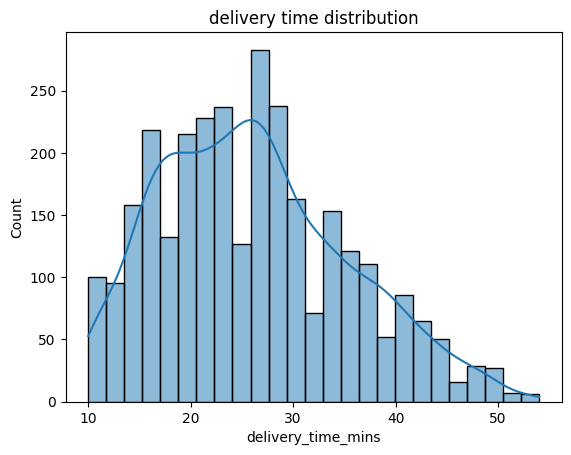

In [49]:
sns.histplot(df["delivery_time_mins"],kde = True)
plt.title("delivery time distribution")
plt.show()

### normally distributed 

<Axes: xlabel='distance_km', ylabel='delivery_time_mins'>

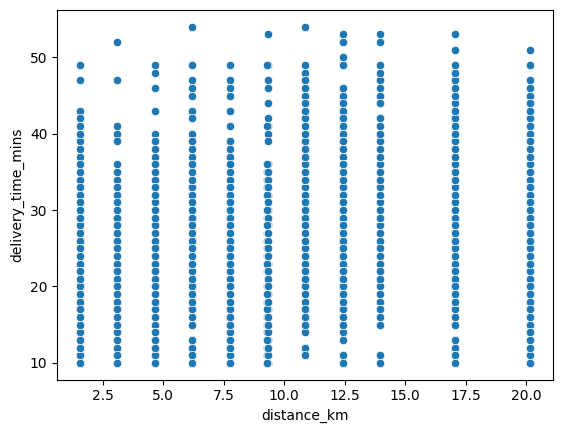

In [52]:
# distance vs delivery time

sns.scatterplot(
    x = 'distance_km',
    y = 'delivery_time_mins',
    data =  df
)

# this is bad there no relation ! 

In [54]:
df['delivery_time_mins'].corr(df['distance_km'])


np.float64(0.3339312156034528)

<Axes: xlabel='Road_traffic_density', ylabel='delivery_time_mins'>

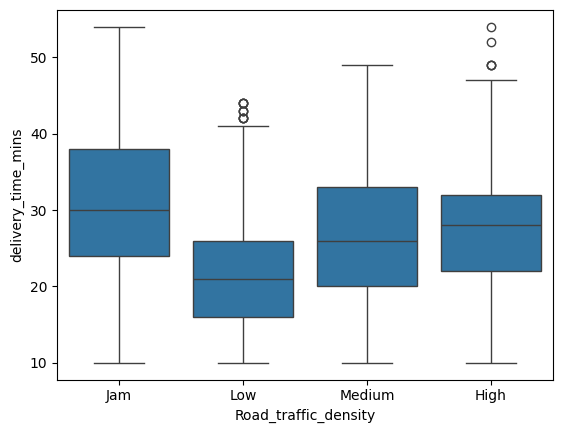

In [55]:
# trafic vs delivery time 

sns.boxplot(x="Road_traffic_density",
            y = "delivery_time_mins",
            data = df)

<Axes: xlabel='weather_clean', ylabel='delivery_time_mins'>

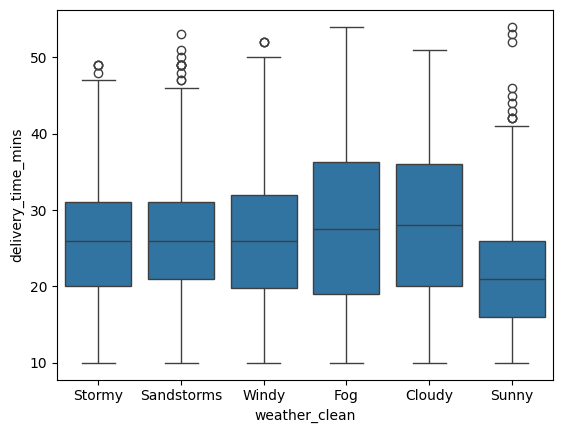

In [57]:
# weather vs delivery time 

sns.boxplot(
    x = "weather_clean",
    y = "delivery_time_mins"
    ,data= df 
)

<Axes: xlabel='multiple_deliveries', ylabel='delivery_time_mins'>

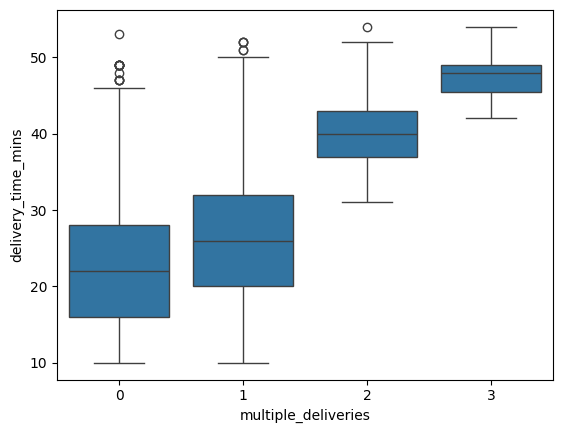

In [58]:
# multiple delivery vs delivery time
sns.boxplot(
    x = "multiple_deliveries",
    y = "delivery_time_mins",
    data = df
)

In [59]:
    
df["multiple_deliveries"].corr(df["delivery_time_mins"])

np.float64(0.35345290013547453)

<Axes: xlabel='Delivery_person_Ratings', ylabel='delivery_time_mins'>

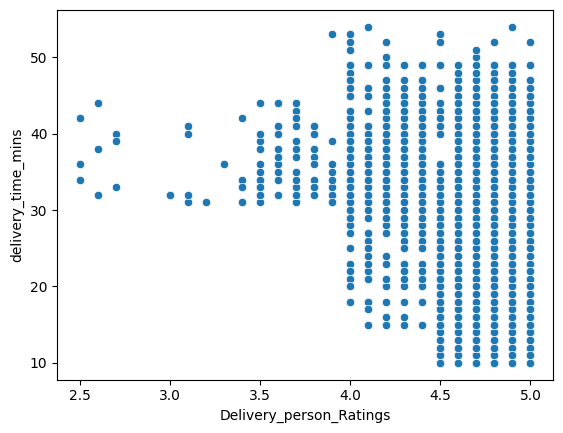

In [60]:
# Driver Rating vs Delivery Time
sns.scatterplot(
    x="Delivery_person_Ratings",
    y="delivery_time_mins",
    data=df
)


<Axes: xlabel='Type_of_vehicle', ylabel='delivery_time_mins'>

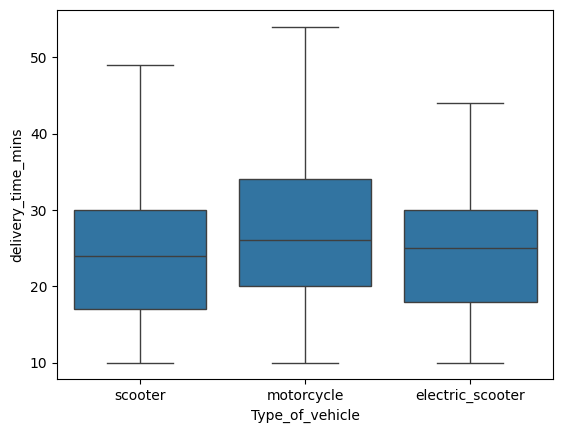

In [63]:
sns.boxplot(
    x="Type_of_vehicle",
    y="delivery_time_mins",
    data=df
)

<Axes: >

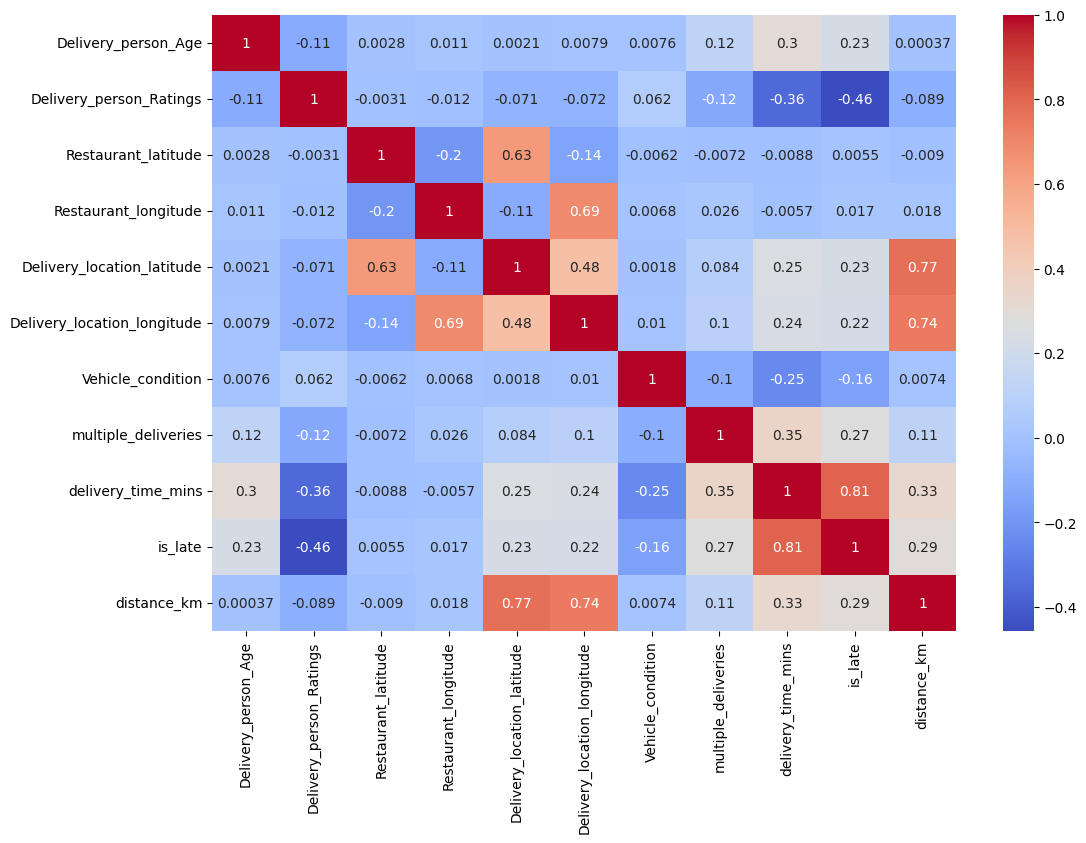

In [61]:
# correaltion matrix

numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)


### EDA Findings

1. Multiple deliveries show a strong positive relationship with delivery time.

2. Road traffic density significantly impacts delivery duration, with traffic jams causing the longest delivery times.

3. Delivery partner ratings exhibit a moderate negative correlation with delivery time, indicating that higher-rated partners tend to deliver faster.

4. Distance contributes positively to delivery time but is not the sole determining factor.

5. Vehicle condition negatively correlates with delivery time, suggesting better-maintained vehicles improve delivery efficiency.

6. Weather conditions influence delivery duration, though the impact appears smaller than traffic density and multiple deliveries.

7. Features such as `is_late` and `Time_taken(min)` may introduce target leakage and should be excluded from regression modeling.